In [1]:
import pandas as pd
import numpy as np

In [2]:
train_set_url = "https://learn.zone01dakar.sn/git/root/public/raw/branch/master/subjects/ai/nlp-scraper/bbc_news_train.csv"
test_set_url = "https://learn.zone01dakar.sn/git/root/public/raw/branch/master/subjects/ai/nlp-scraper/bbc_news_tests.csv"
train_data = pd.read_csv(train_set_url, index_col="ArticleId")
test_data = pd.read_csv(test_set_url, index_col="ArticleId")

train_data.sort_index(axis=0, inplace=True)
test_data.sort_index(axis=0, inplace=True)
test_data.drop(columns=["Unnamed: 0"], inplace=True)

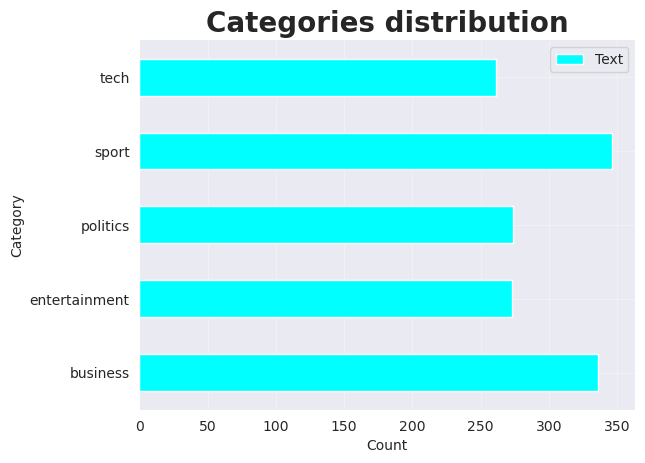

In [3]:
import matplotlib.pyplot as plt
train_data.groupby("Category").count().plot(kind="barh", ylabel="Category", xlabel="Count", legend=True, color="cyan")
plt.grid(True, alpha=0.3)
plt.title("Categories distribution", fontdict={"size": 20, "weight": "bold"})
plt.gca().spines[["right", "top"]].set_visible(False)
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder
import spacy
from utils.tools import remove_punctuation

nlp = spacy.load("en_core_web_lg")
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    label_encoder = LabelEncoder()
    text =df.iloc[:,0].astype(str)
    return pd.DataFrame({
        "Text_vector": text.apply(lambda x: nlp(remove_punctuation(x)).vector),
        "Category": label_encoder.fit_transform(df.iloc[:,1])
    })

In [5]:
prep_test = preprocess(test_data)
prep_train = preprocess(train_data)

In [6]:
x_train, y_train = prep_train["Text_vector"], prep_train["Category"]
x_test, y_test = prep_test["Text_vector"], prep_test["Category"]

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": np.arange(1,3),
            "weights": ["uniform", "distance"],
            "leaf_size": np.arange(1, 3),
        }
    },
    "DecisionTree": {
        "model": DecisionTreeClassifier(),
        "params": {
            "criterion": ["gini", "entropy", "log_loss"],
            "max_depth": np.arange(1, 5),
            "max_features": [1],
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": np.arange(1,5),
            "max_depth": np.arange(1, 5),
            "max_features": np.arange(1, 5),
            "criterion": ["gini", "entropy", "log_loss"],
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(),
        "params": {
            "n_estimators": np.arange(1, 5),
            "max_depth": np.arange(1, 5),
            "max_features": [1],
            "learning_rate": np.arange(0.0, 10.0 ),
        }
    }
}

In [8]:
from sklearn.preprocessing import LabelEncoder
transformer = LabelEncoder().fit(['business', 'entertainment', 'politics', 'sport', 'tech'])

In [9]:
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, f1_score, log_loss
from sklearn.model_selection import RandomizedSearchCV, learning_curve, GridSearchCV

def check_model_performance(model_list: dict, xtrain, ytrain, xtest, ytest) -> pd.DataFrame:
    print("Starting model performance checking ...")
    res = pd.DataFrame()
    for model_name, info in model_list.items():
        print(f"\t- checking best params for Model :{model_name}")
        grid_search = GridSearchCV(estimator=info["model"],
                                   param_grid=info["params"],
                                   scoring=["accuracy", "neg_log_loss"],
                                   refit="neg_log_loss",
                                   cv=5,
                                   n_jobs=-1)
        grid_search.fit(xtrain, ytrain)
        best_params = grid_search.best_params_
        print(f"\t- best parameters for {model_name} are : {best_params}")

        print(f"\ttraining {model_name} ...", flush=True)
        model  = grid_search.best_estimator_
        model.fit(xtrain, ytrain)

        print(f"\t- predicting on x_test ...", flush=True)
        y_pred = model.predict(xtest)

        print(f"\t- computing metrics ...", flush=True)
        score = model.score(xtrain, ytrain)
        acc=accuracy_score(ytest, y_pred)
        rec = recall_score(ytest, y_pred, average="macro")
        _f1 = f1_score(ytest, y_pred, average="macro")
        log_l = log_loss(
            transformer.fit_transform(ytest),
            model.predict_proba(xtest),
        )
        res[model_name] = {
            "Score": score,
            "Accuracy": acc,
            "Recall": rec,
            "F1": _f1,
            "log_loss": log_l,
            "best_params": best_params,
        }

        train_sizes, train_scores, test_scores = learning_curve(
            model, xtrain, ytrain, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring="neg_log_loss"
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.figure(figsize=(5, 5), facecolor="w", edgecolor="k")
        plt.plot(train_sizes, train_mean, label="training score", color='blue')
        plt.plot(train_sizes, test_mean, label="validation score", color='red')

        #trust interval
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')

        plt.title(f"learning curve of {model_name}")
        plt.xlabel("training size")
        plt.ylabel("Neg Log Loss")
        plt.legend(loc="best")
        plt.grid(True)
        print("\t- learning curve done")
    plt.show()
    print("End of model performance checking ...")
    return res

Starting model performance checking ...
	- checking best params for Model :KNN
	- best parameters for KNN are : {'leaf_size': np.int64(1), 'n_neighbors': np.int64(2), 'weights': 'distance'}
	training KNN ...
	- predicting on x_test ...
	- computing metrics ...
	- learning curve done
	- checking best params for Model :DecisionTree
	- best parameters for DecisionTree are : {'criterion': 'gini', 'max_depth': np.int64(3), 'max_features': 1}
	training DecisionTree ...
	- predicting on x_test ...
	- computing metrics ...
	- learning curve done
	- checking best params for Model :RandomForest
	- best parameters for RandomForest are : {'criterion': 'entropy', 'max_depth': np.int64(4), 'max_features': np.int64(4), 'n_estimators': np.int64(4)}
	training RandomForest ...
	- predicting on x_test ...
	- computing metrics ...
	- learning curve done
	- checking best params for Model :GradientBoosting
	- best parameters for GradientBoosting are : {'learning_rate': np.float64(1.0), 'max_depth': np.int64

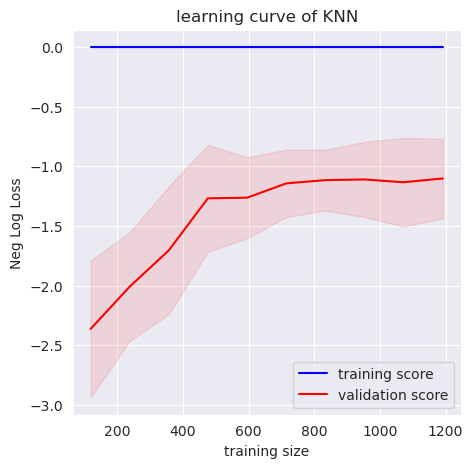

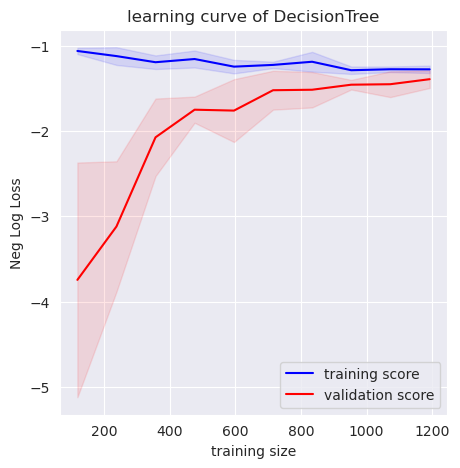

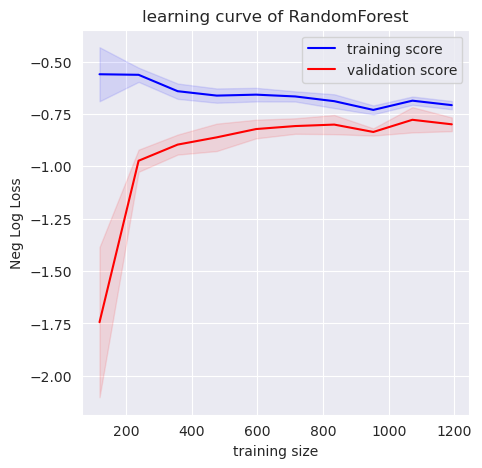

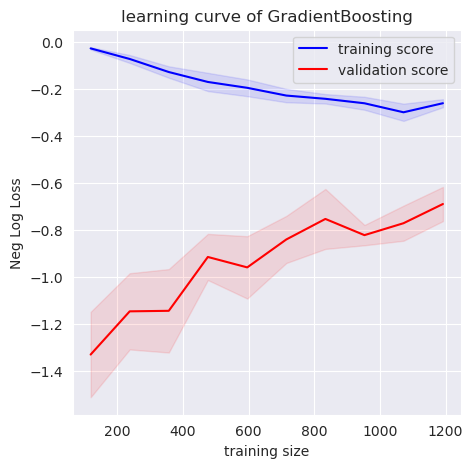

End of model performance checking ...


In [10]:
perf_tab = check_model_performance(models,
                        np.vstack(x_train),
                        y_train,
                        np.vstack(x_test),
                        y_test.values)

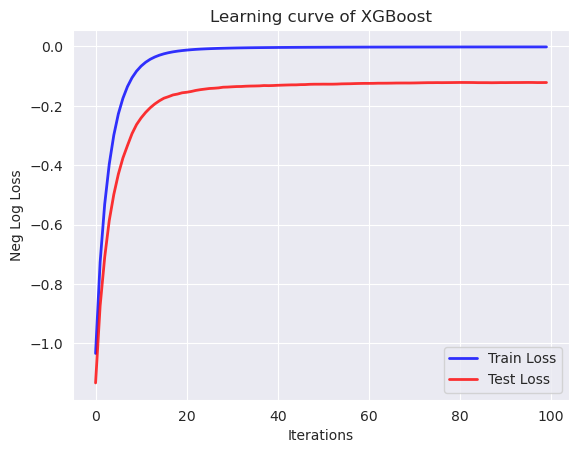

In [11]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

xgb.fit(np.vstack(x_train), y_train,
          eval_set=[(np.vstack(x_train), y_train),(np.vstack(x_test), y_test)],
          verbose=False)

train_score = xgb.score(np.vstack(x_train), y_train)
test_score = xgb.score(np.vstack(x_test), y_test)

accuracy = accuracy_score(y_test, xgb.predict(np.vstack(x_test)))
recall = recall_score(y_test, xgb.predict(np.vstack(x_test)), average="macro")
f1 = f1_score(y_test, xgb.predict(np.vstack(x_test)), average="macro")
ll = log_loss(
    transformer.fit_transform(y_test),
    xgb.predict_proba(np.vstack(x_test)),
)

xgbost_perf = pd.Series({
"XGBOOST":
    [
        train_score,
        accuracy,
        recall,
        f1,
        ll,
        "",
    ]
})

results =  xgb.evals_result()
# learning curve
validation_0 =  np.array(results["validation_0"]["mlogloss"]).__mul__(-1)
validation_1 = np.array(results["validation_1"]["mlogloss"]).__mul__(-1)
plt.plot(validation_0, label="Train Loss", color='blue', linewidth=2, alpha=0.8)
plt.plot(validation_1, label="Test Loss", color='red', linewidth=2, alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("Neg Log Loss")
plt.title("Learning curve of XGBoost")
plt.legend(loc="best")
plt.grid(True)
plt.legend()
plt.savefig("xgboost_learning curve.png")

In [12]:
perf_tab["XGBOOST"] = xgbost_perf["XGBOOST"]
perf_tab

,KNN,DecisionTree,RandomForest,GradientBoosting,XGBOOST
Score,1.0,0.550336,0.82349,0.900671,1.0
Accuracy,0.957823,0.488435,0.778231,0.770068,0.960544
Recall,0.958097,0.486402,0.76349,0.766541,0.960332
F1,0.957746,0.475969,0.767244,0.766951,0.960581
log_loss,0.971194,1.373273,0.829046,0.747999,0.121571
best_params,"{'leaf_size': 1, 'n_neighbors': 2, 'weights': ...","{'criterion': 'gini', 'max_depth': 3, 'max_fea...","{'criterion': 'entropy', 'max_depth': 4, 'max_...","{'learning_rate': 1.0, 'max_depth': 4, 'max_fe...",


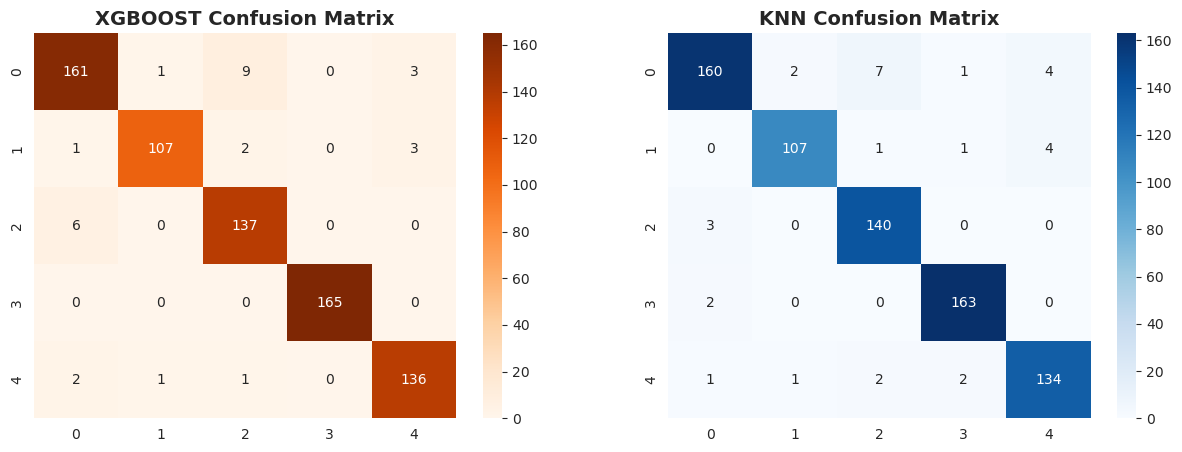

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, xgb.predict(np.vstack(x_test)))
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax[0])
ax[0].set_title("XGBOOST Confusion Matrix", fontsize=14, fontweight="bold")

params = perf_tab.loc["best_params", "KNN"]
knn = KNeighborsClassifier(n_neighbors=params["n_neighbors"], leaf_size=params["leaf_size"], weights=params["weights"])
knn.fit(np.vstack(x_train), y_train)

cm1 = confusion_matrix(y_test, knn.predict(np.vstack(x_test)))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", ax=ax[1])
ax[1].set_title("KNN Confusion Matrix", fontsize=14, fontweight="bold")
plt.savefig("xgboost vs KNN confusion_matrix.png")


In [ ]:
print(f"Chosen model is XGBOOSTCLASSIFIER with an accuracy of {}")

In [14]:
import joblib
joblib.dump(xgb, "../topic_classifier.pkl")

['../topic_classifier.pkl']